# Hybrid OD Matrix — Empirical-Bayes Shrinkage of Survey toward Cellular

Treats the cellular matrix as the prior spatial distribution $P^{cell}(B|A)$ and the weighted survey as evidence, blending per origin superzone $A$:

$$ P^*(B|A) = \lambda_A\, P^{survey}(B|A) + (1-\lambda_A)\, P^{cell}(B|A), \qquad \lambda_A = \frac{n_A}{n_A + k} $$

- $P^{survey}$: the **household-weighted** superzone probabilities (population-representative pattern)
- $n_A$: the **unweighted** number of survey trips departing superzone $A$ — statistical information is the number of observations, not the expanded weight
- $k$: the shrinkage constant, chosen by **cross-day validation**: blend Day 10 with cellular and score how well it predicts Day 20, and vice versa, over candidate $k \in \{20, 50, 100, 200, 500\}$ (extended with $\{0, 1, 2, 5, 10, 1000, \infty\}$ to expose the full curve — $k=0$ is pure survey, $k=\infty$ pure cellular). Primary metric: mean row-wise Jensen–Shannon divergence (base 2); MAE reported alongside.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2 = '#0b0b0b', '#52514e'

## 1. Inputs — superzone counts per survey day, cellular prior

In [2]:
df = pd.read_csv('Input/Matrices/ACTIVITIES_DEC18_corrected.csv')
weights = pd.read_csv('Input/Matrices/households_with_weights.csv')[['HHID', 'wf_new']]
df = df.merge(weights, on='HHID', how='left', validate='many_to_one')

keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
keys_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER'])
keys_sz['TAZ_NUMBER'] = keys_sz['TAZ_NUMBER'].astype(int)
taz_to_sz = keys_sz.set_index('TAZ_NUMBER')['SZ_NEW'].to_dict()

def am_peak_trips(df_day):
    d = df_day.sort_values(by=['INDIVID', 'tourID', 'ACT_ID'])
    d['origin'] = d.groupby(['INDIVID', 'tourID'])['taz'].shift(1)
    d['destination'] = d['taz']
    d['StartTime'] = pd.to_datetime(d['StartTime'], dayfirst=True)
    d['EndTime'] = pd.to_datetime(d['EndTime'], dayfirst=True)
    d['leaving_time'] = pd.to_datetime(np.where(d['mainActivity'] == 'Home', d['EndTime'], d['StartTime']))
    mask = (d['leaving_time'].dt.hour >= 6) & (d['leaving_time'].dt.hour < 9)
    f = d[mask].dropna(subset=['origin', 'destination']).copy()
    # model-area trips only: both ends must have a real TAZ; Default arrival = no reported travel
    f = f[(f['origin'] != 0) & (f['destination'] != 0) & (f['MODE_NAME'] != 'Default')]
    f['origin_sz'] = f['origin'].map(taz_to_sz)
    f['dest_sz'] = f['destination'].map(taz_to_sz)
    return f.dropna(subset=['origin_sz', 'dest_sz'])

t10 = am_peak_trips(df[df['ACT_DAY'] == 10])
t20 = am_peak_trips(df[df['ACT_DAY'] == 20])

# cellular prior at superzone level (validated reconstruction, as in the comparison notebook)
cellular = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')[['fromZone', 'ToZone', 'h6', 'h7', 'h8']]
keys = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER'])
keys['TAZ_NUMBER'] = keys['TAZ_NUMBER'].astype(int)
keys = keys.drop_duplicates(subset=['TAZ_NUMBER'])
c = cellular.merge(keys.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'fromTaz'}), on='fromZone')
c = c.merge(keys.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'ToTaz'}), on='ToZone')
c['origin_sz'] = c['fromTaz'].map(taz_to_sz)
c['dest_sz'] = c['ToTaz'].map(taz_to_sz)
cell_sz = c.dropna(subset=['origin_sz', 'dest_sz']).groupby(['origin_sz', 'dest_sz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)
SZ = cell_sz.index
P_cell = cell_sz.div(cell_sz.sum(axis=1), axis=0).fillna(0)

def sz_matrix(trips, weighted):
    v = trips.groupby(['origin_sz', 'dest_sz'])['wf_new'].sum() if weighted else trips.groupby(['origin_sz', 'dest_sz']).size()
    return v.unstack().fillna(0).reindex(index=SZ, columns=SZ, fill_value=0)

W10, W20 = sz_matrix(t10, True), sz_matrix(t20, True)     # weighted trip totals
N10, N20 = sz_matrix(t10, False), sz_matrix(t20, False)   # raw observation counts
P10 = W10.div(W10.sum(axis=1), axis=0).fillna(0)
P20 = W20.div(W20.sum(axis=1), axis=0).fillna(0)
n10, n20 = N10.sum(axis=1), N20.sum(axis=1)

print(f"survey observations per origin SZ — day 10: min {n10.min():.0f}, median {n10.median():.0f}, max {n10.max():.0f}")
print(f"                                    day 20: min {n20.min():.0f}, median {n20.median():.0f}, max {n20.max():.0f}")

survey observations per origin SZ — day 10: min 91, median 352, max 943
                                    day 20: min 103, median 348, max 880


## 2. Blending and evaluation machinery

In [3]:
def blend(P_survey, n, k):
    '''P* = lambda_A * P_survey + (1 - lambda_A) * P_cell, lambda_A = n_A / (n_A + k)'''
    lam = (n / (n + k)).values if np.isfinite(k) else np.zeros(len(n))
    return P_survey.mul(lam, axis=0) + P_cell.mul(1 - lam, axis=0)

def jsd_row(p, q):
    '''Jensen-Shannon divergence (base 2) between two probability rows.'''
    p, q = np.asarray(p, float), np.asarray(q, float)
    if p.sum() == 0 or q.sum() == 0:
        return np.nan
    p, q = p / p.sum(), q / q.sum()
    m = (p + q) / 2
    kl = lambda a, b: np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0]))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def evaluate(P_pred, P_target):
    jsd = np.array([jsd_row(P_pred.loc[a], P_target.loc[a]) for a in SZ])
    return float(np.nanmean(jsd)), float(np.mean(np.abs(P_pred.values - P_target.values)))

## 3. Cross-day validation of $k$

In [4]:
ks = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, np.inf]
rows = []
for k in ks:
    jsd_a, mae_a = evaluate(blend(P10, n10, k), P20)   # Day 10 blend -> predict Day 20
    jsd_b, mae_b = evaluate(blend(P20, n20, k), P10)   # Day 20 blend -> predict Day 10
    rows.append({'k': k, 'JSD 10->20': jsd_a, 'JSD 20->10': jsd_b,
                 'JSD avg': (jsd_a + jsd_b) / 2, 'MAE avg': (mae_a + mae_b) / 2})
cv = pd.DataFrame(rows).set_index('k')
k_star = cv['JSD avg'].idxmin()
print(f"optimal k (JSD): {k_star}   |   best of the candidate set {{20,50,100,200,500}}: "
      f"{cv.loc[[20,50,100,200,500],'JSD avg'].idxmin()}")
cv.round(5)

optimal k (JSD): 2.0   |   best of the candidate set {20,50,100,200,500}: 20.0


,JSD 10->20,JSD 20->10,JSD avg,MAE avg
k,,,,
0.0,0.01570,0.01570,0.01570,0.00307
1.0,0.01564,0.01555,0.01559,0.00307
2.0,0.01564,0.01549,0.01557,0.00308
5.0,0.01581,0.01554,0.01568,0.00312
10.0,0.01638,0.01597,0.01617,0.00324
20.0,0.01802,0.01746,0.01774,0.00356
50.0,0.02435,0.02366,0.02400,0.00482
100.0,0.03535,0.03471,0.03503,0.00674
200.0,0.05422,0.05378,0.05400,0.00955


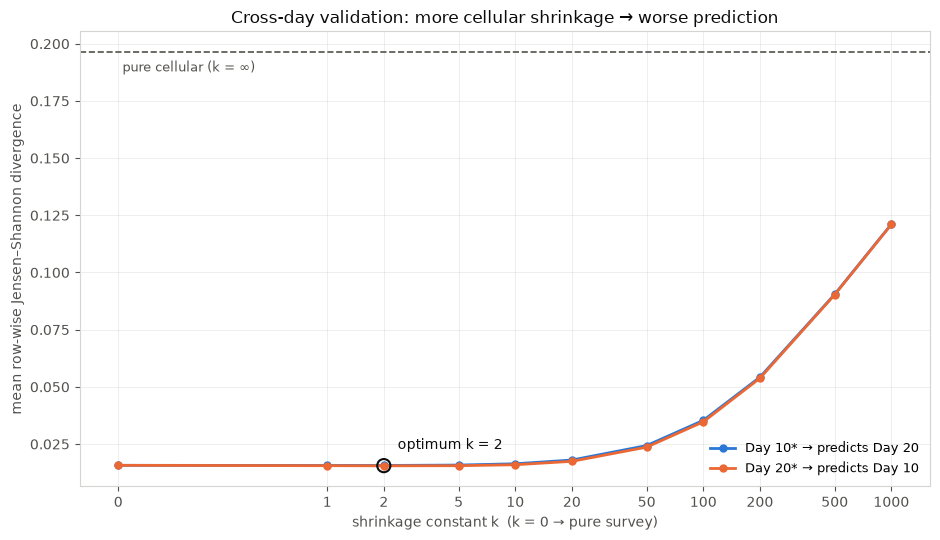

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5.5), facecolor='white')
finite = cv.index[np.isfinite(cv.index)]
x = finite.values
ax.plot(x, cv.loc[finite, 'JSD 10->20'], color=BLUE, linewidth=2, marker='o', markersize=5, label='Day 10* → predicts Day 20')
ax.plot(x, cv.loc[finite, 'JSD 20->10'], color=ORANGE, linewidth=2, marker='o', markersize=5, label='Day 20* → predicts Day 10')
ax.axhline(cv.loc[np.inf, 'JSD avg'], color=INK2, linestyle='--', linewidth=1.2)
ax.annotate('pure cellular (k = ∞)', xy=(0.02, cv.loc[np.inf, 'JSD avg']), xytext=(0, -14),
            textcoords='offset points', color=INK2, fontsize=9)
ax.scatter([k_star], [cv.loc[k_star, 'JSD avg']], s=90, facecolor='none', edgecolor=INK, linewidth=1.5, zorder=5)
ax.annotate(f'optimum k = {k_star:g}', xy=(k_star, cv.loc[k_star, 'JSD avg']), xytext=(10, 12),
            textcoords='offset points', color=INK, fontsize=10)
ax.set_xscale('symlog', linthresh=1)
ax.set_xticks([0, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000])
ax.set_xticklabels(['0', '1', '2', '5', '10', '20', '50', '100', '200', '500', '1000'])
ax.set_xlabel('shrinkage constant k  (k = 0 → pure survey)', color=INK2)
ax.set_ylabel('mean row-wise Jensen–Shannon divergence', color=INK2)
ax.set_title('Cross-day validation: more cellular shrinkage → worse prediction', color=INK, fontsize=12)
ax.grid(True, alpha=0.25, linewidth=0.6)
for s in ax.spines.values(): s.set_color('#d5d4d0')
ax.tick_params(colors=INK2)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('Output/figures/hybrid_cv_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Off-diagonal check

Because the diagonal (intra-superzone) cells carry the known systematic survey–cellular divergence, the same CV restricted to **destinations outside the origin superzone** (rows renormalized without the diagonal) checks whether cellular helps predict where trips go once they leave the zone.

In [6]:
def evaluate_offdiag(P_pred, P_target):
    vals = []
    for i, a in enumerate(SZ):
        p, q = P_pred.loc[a].values.copy(), P_target.loc[a].values.copy()
        p[i] = 0; q[i] = 0
        vals.append(jsd_row(p, q))
    return float(np.nanmean(vals))

od = {k: (evaluate_offdiag(blend(P10, n10, k), P20) + evaluate_offdiag(blend(P20, n20, k), P10)) / 2
      for k in ks}
od = pd.Series(od, name='off-diagonal JSD avg')
print(f"off-diagonal optimum: k = {od.idxmin():g}")
od.round(5).to_frame()

off-diagonal optimum: k = 2


,off-diagonal JSD avg
0.0,0.05672
1.0,0.05624
2.0,0.05606
5.0,0.05607
10.0,0.05691
20.0,0.05971
50.0,0.06952
100.0,0.08347
200.0,0.10228
500.0,0.12882


## 4. Final hybrid matrix

The CV verdict: the JSD curve is minimized at $k^* = 2$ and is flat over $k \in [0, 5]$ — among the original candidates $\{20,\dots,500\}$, $k=20$ is best, and the curve rises monotonically beyond it. The final hybrid pools both survey days (summed weighted counts; $n_A$ = pooled raw observations) and blends with cellular at $k^* = 2$. A $k = 100$ variant is exported alongside as a sensitivity case.

In [7]:
W_pool = W10 + W20
N_pool_n = n10 + n20
P_pool = W_pool.div(W_pool.sum(axis=1), axis=0).fillna(0)

K_STAR, K_SENS = 2, 100
P_hybrid = blend(P_pool, N_pool_n, K_STAR)
P_hybrid_k100 = blend(P_pool, N_pool_n, K_SENS)

lam = pd.DataFrame({
    'n_A (pooled obs)': N_pool_n.astype(int),
    f'lambda (k={K_STAR})': N_pool_n / (N_pool_n + K_STAR),
    f'lambda (k={K_SENS})': N_pool_n / (N_pool_n + K_SENS),
})
lam.index.name = 'origin_sz'
print(f"pooled n_A: min {N_pool_n.min():.0f}, median {N_pool_n.median():.0f}, max {N_pool_n.max():.0f}")
print(f"lambda at k={K_STAR}:  {lam.iloc[:,1].min():.4f} – {lam.iloc[:,1].max():.4f}")
print(f"lambda at k={K_SENS}: {lam.iloc[:,2].min():.4f} – {lam.iloc[:,2].max():.4f}")
lam.head(8).round(4)

pooled n_A: min 194, median 696, max 1823
lambda at k=2:  0.9898 – 0.9989
lambda at k=100: 0.6599 – 0.9480


,n_A (pooled obs),lambda (k=2),lambda (k=100)
origin_sz,,,
1,1001,0.9980,0.9092
2,1191,0.9983,0.9225
3,1537,0.9987,0.9389
4,1290,0.9985,0.9281
5,382,0.9948,0.7925
6,511,0.9961,0.8363
7,528,0.9962,0.8408
8,664,0.9970,0.8691


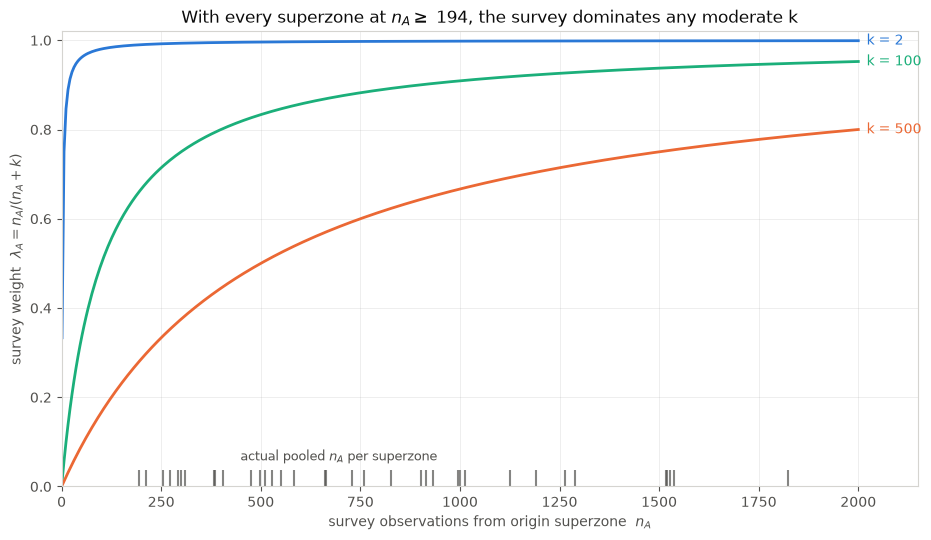

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 5.5), facecolor='white')
n_grid = np.linspace(1, 2000, 400)
for k, color in [(2, BLUE), (100, AQUA), (500, ORANGE)]:
    ax.plot(n_grid, n_grid / (n_grid + k), color=color, linewidth=2)
    ax.annotate(f'k = {k}', xy=(2000, 2000 / (2000 + k)), xytext=(6, 0),
                textcoords='offset points', color=color, fontsize=10, va='center')
ax.scatter(N_pool_n.values, np.full(len(N_pool_n), 0.02), marker='|', s=120, color=INK2, alpha=0.7)
ax.annotate('actual pooled $n_A$ per superzone', xy=(float(N_pool_n.median()), 0.02), xytext=(0, 12),
            textcoords='offset points', color=INK2, fontsize=9, ha='center')
ax.set_xlim(0, 2150); ax.set_ylim(0, 1.02)
ax.set_xlabel('survey observations from origin superzone  $n_A$', color=INK2)
ax.set_ylabel('survey weight  $\lambda_A = n_A / (n_A + k)$', color=INK2)
ax.set_title('With every superzone at $n_A \geq$ 194, the survey dominates any moderate k', color=INK, fontsize=12)
ax.grid(True, alpha=0.25, linewidth=0.6)
for s in ax.spines.values(): s.set_color('#d5d4d0')
ax.tick_params(colors=INK2)
plt.tight_layout()
plt.savefig('Output/figures/hybrid_lambda_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Hybrid trips matrix: P* rows scaled to average-weekday expanded AM-peak departures per origin
origin_volumes = (W10.sum(axis=1) + W20.sum(axis=1)) / 2
T_hybrid = P_hybrid.mul(origin_volumes, axis=0)

P_hybrid.to_csv('Output/hybrid_sz_prob.csv')
P_hybrid_k100.to_csv('Output/hybrid_sz_prob_k100.csv')
T_hybrid.to_csv('Output/hybrid_sz_trips.csv')
lam.to_csv('Output/hybrid_lambda.csv')
cv.to_csv('Output/hybrid_cv_results.csv')
print(f"hybrid trips total (avg weekday AM peak): {T_hybrid.sum().sum():,.0f}")
print("saved: hybrid_sz_prob.csv, hybrid_sz_prob_k100.csv, hybrid_sz_trips.csv, hybrid_lambda.csv, hybrid_cv_results.csv")

hybrid trips total (avg weekday AM peak): 2,152,928
saved: hybrid_sz_prob.csv, hybrid_sz_prob_k100.csv, hybrid_sz_trips.csv, hybrid_lambda.csv, hybrid_cv_results.csv


## 5. Findings and interpretation

**1. Cross-day validation selects (almost) no shrinkage.** Mean row-wise JSD: 0.0156 at $k^*=2$ vs 0.0157 pure survey, 0.0177 at $k=20$, 0.0350 at $k=100$, and 0.196 pure cellular. The curve rises monotonically beyond $k\approx5$; among the proposed candidates $\{20, 50, 100, 200, 500\}$, $k=20$ wins. MAE agrees with JSD throughout. The off-diagonal variant tells the same story (optimum $k \approx 2$–$5$, ~1% below $k=0$): cellular barely helps even for predicting where trips go once they leave the zone.

**2. Why: superzone rows are already well-estimated, and the divergence from cellular is systematic.** Every origin superzone has $n_A \geq 91$ observations per day ($\geq 194$ pooled, median ≈ 700), so survey sampling noise at this resolution is small — while the survey–cellular gap (above all the 72% vs 34% intra-zone share) is structural, not noise. Shrinking toward a systematically different prior moves the estimate away from anything the survey measures.

**3. Honest caveat: this CV measures internal consistency, not truth.** Days 10 and 20 come from the *same households*, so predicting one day from the other cannot detect biases shared by both (reporting behavior, sample composition). The CV result says the survey is highly self-consistent at superzone level — it cannot prove the survey is closer to reality than cellular where they disagree. The diagonal divergence remains an open question that this procedure, by construction, resolves in the survey's favor.

**4. Where the shrinkage framework will genuinely matter: TAZ level.** At superzone resolution the sample is rich; at TAZ resolution (778 zones, ~29 trips per origin on average, most cells empty) $n_A$ is small and $\lambda_A$ would give cellular substantial weight exactly where the survey is unreliable. Applying this same estimator at TAZ level — with the superzone hybrid as an intermediate prior — is the natural next step.

**Deliverables:** `hybrid_sz_prob.csv` ($k^*=2$, pooled survey — effectively survey with a light cellular floor, $\lambda_A \geq 0.99$), `hybrid_sz_prob_k100.csv` (sensitivity variant, $\lambda_A \approx 0.66$–$0.95$), `hybrid_sz_trips.csv` (rows scaled to average-weekday expanded AM-peak departures), `hybrid_lambda.csv`, `hybrid_cv_results.csv`.